In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# Funciones

In [ ]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [ ]:
def agrupacion(df,columnas,umbral=0.02,categoria_agrupada='Otros'):
  df_agrupado = df.copy()
  for col in columnas:
    frecuencias = df_agrupado[col].value_counts(normalize=True)
    categorias_poco_frecuentes = frecuencias[frecuencias < umbral].index
    df_agrupado[col] = df_agrupado[col].replace(categorias_poco_frecuentes, categoria_agrupada)
  return df_agrupado

In [ ]:
def aplicar_agrupacion(df, col, categorias_poco_frecuentes, categoria_agrupada='Otros'):
    return df[col].replace(categorias_poco_frecuentes, categoria_agrupada)

# Cargado de datos

In [ ]:
data_url = 'https://docs.google.com/spreadsheets/d/1_KCCMLmD6jYINRbLJwud-moSgEkevpdJtc8VIbZuAVM/export?format=csv'

In [ ]:
df = pd.read_csv(data_url)

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

# Analisis exploratorio de datos

In [ ]:
Summary(df, 'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,4424,37,0,0



Encabezado:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Las columnas de Curriculum units(grade) en ambos semestres no tienen un redondeo universal en los datos por lo que se realizara ese redondeo a 2 decimas debido a que son notas

In [ ]:
df['Curricular units 1st sem (grade)']=df['Curricular units 1st sem (grade)'].round(2)
df['Curricular units 2nd sem (grade)']=df['Curricular units 2nd sem (grade)'].round(2)

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.00,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.67,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.00,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.40,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.00,0,13.9,-0.3,0.79,Graduate


debemos tomar en cuenta que algunas de las variables numericas en realidad tienen categorias asignadas a cada uno de sus datos. Por lo que debemos tener cuidado al tratarlos

Se realizara primero el analisis de las variables numericas que no tienen categorias asignadas a ellas

In [ ]:
numericas=['Previous qualification (grade)','Admission grade','Age at enrollment','Curricular units 1st sem (approved)','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (without evaluations)',
'Curricular units 2nd sem (approved)','Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (without evaluations)','GDP']

In [ ]:
df[numericas].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (without evaluations),GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,4.706600,0.709991,6.270570,8.299051,0.137658,4.435805,0.541817,6.232143,8.063291,0.150316,0.001969
std,13.188332,14.482001,7.587816,3.094238,2.360507,2.480178,4.179106,0.690880,3.014764,1.918546,2.195951,3.947951,0.753774,2.269935
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.060000
25%,125.000000,117.900000,19.000000,3.000000,0.000000,5.000000,6.000000,0.000000,2.000000,0.000000,5.000000,6.000000,0.000000,-1.700000
50%,133.100000,126.100000,20.000000,5.000000,0.000000,6.000000,8.000000,0.000000,5.000000,0.000000,6.000000,8.000000,0.000000,0.320000
75%,140.000000,134.800000,25.000000,6.000000,0.000000,7.000000,10.000000,0.000000,6.000000,0.000000,7.000000,10.000000,0.000000,1.790000
max,190.000000,190.000000,70.000000,26.000000,20.000000,26.000000,45.000000,12.000000,20.000000,19.000000,23.000000,33.000000,12.000000,3.510000


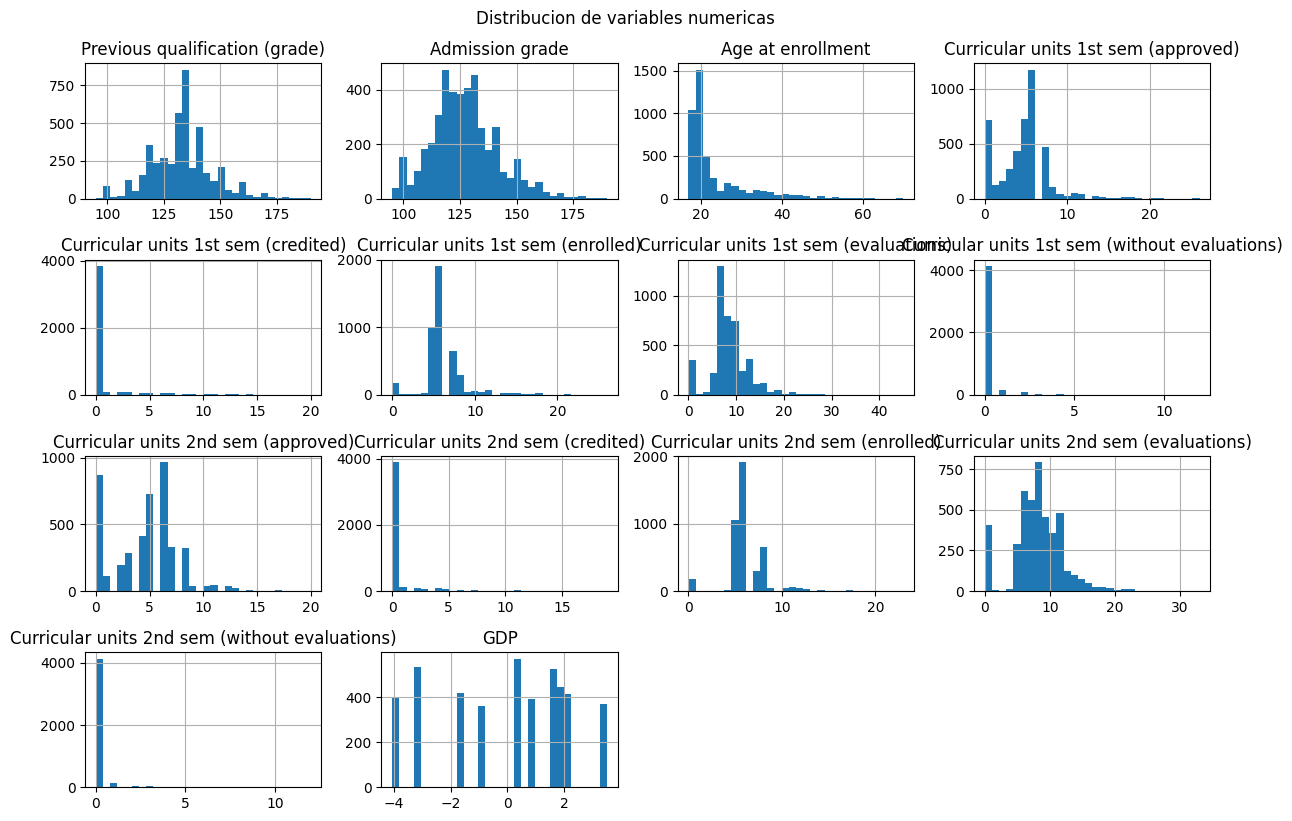

In [ ]:
df[numericas].hist(bins=30,figsize=(12,8))
plt.tight_layout()
plt.suptitle('Distribucion de variables numericas',y=1.02)
plt.show()

añadimos tambien las que representan porcentajes

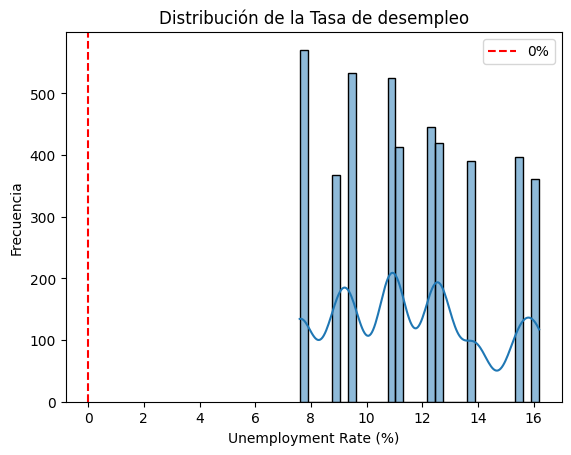

In [ ]:
sns.histplot(data=df, x='Unemployment rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de desempleo')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

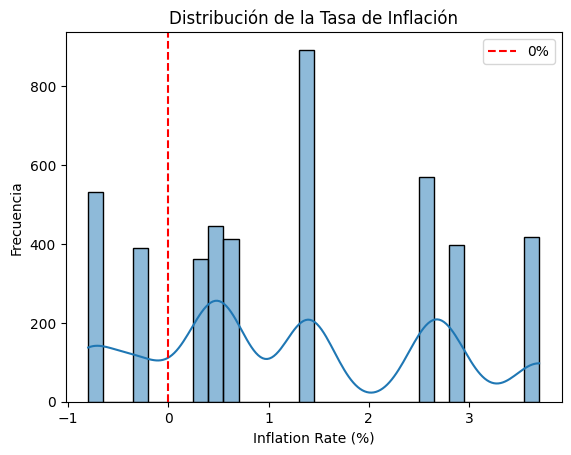

In [ ]:
sns.histplot(data=df, x='Inflation rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de Inflación')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

realizamos boxplots para determinar la presencia de outliers en las variables numericas

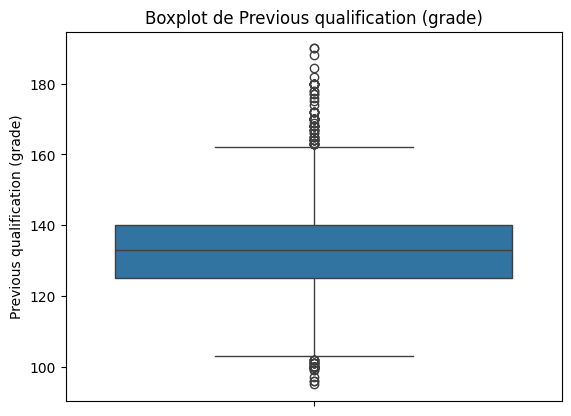

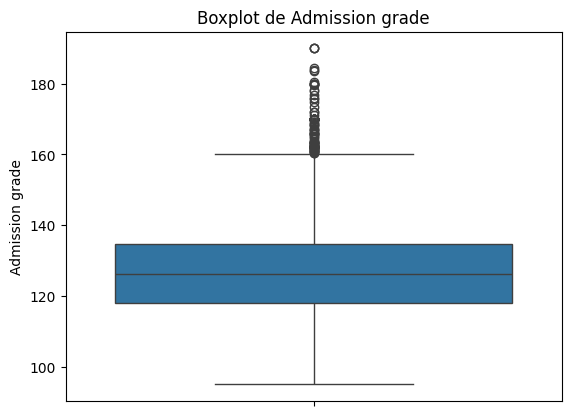

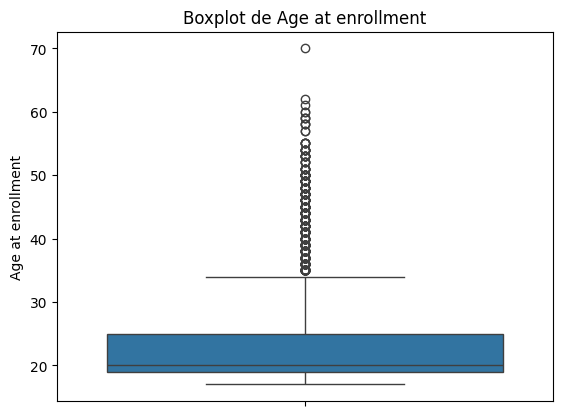

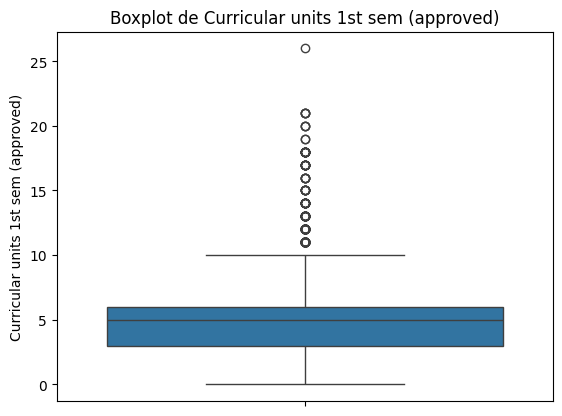

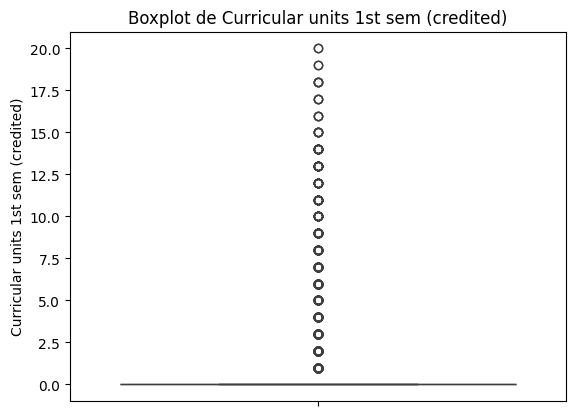

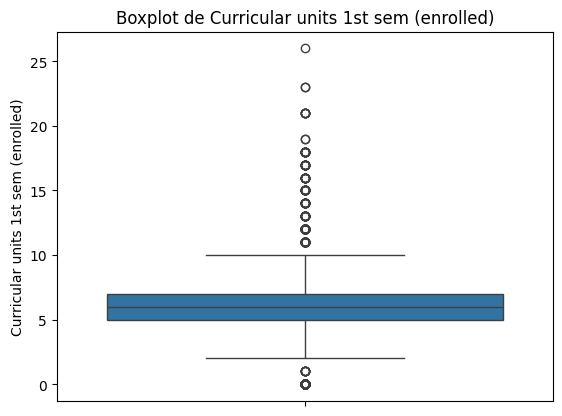

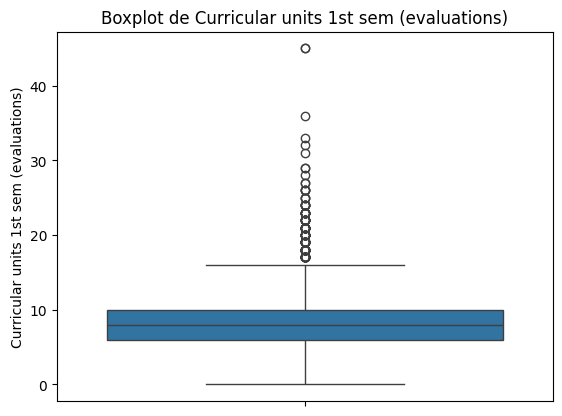

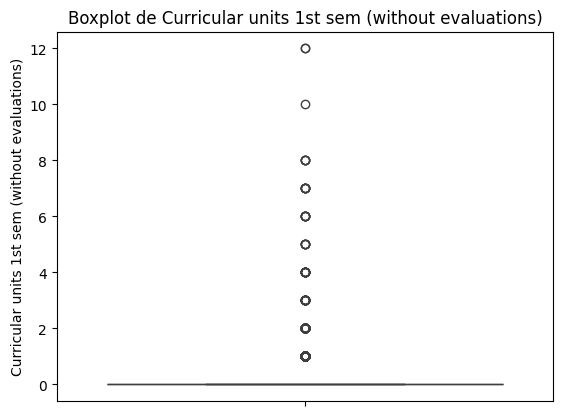

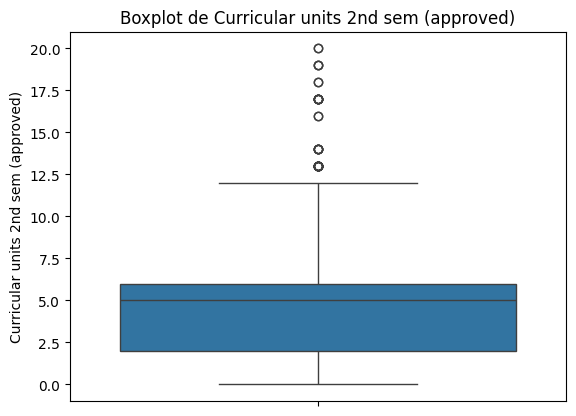

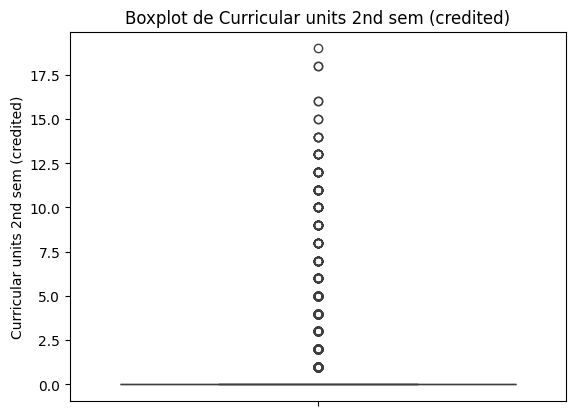

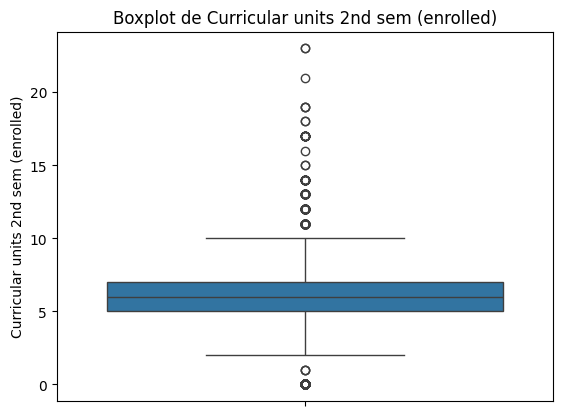

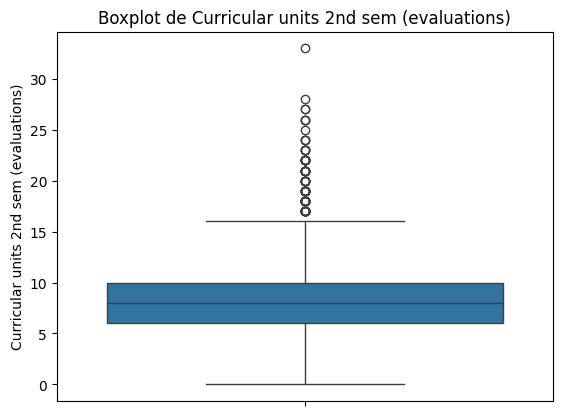

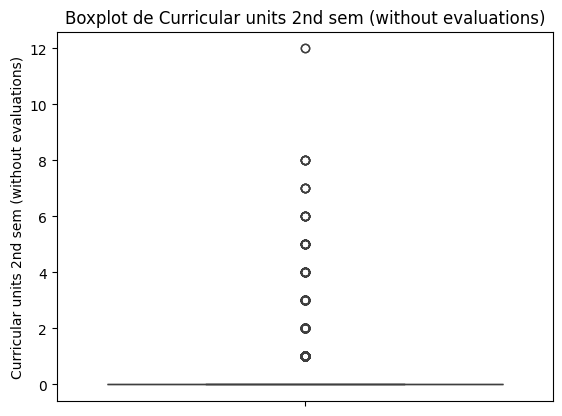

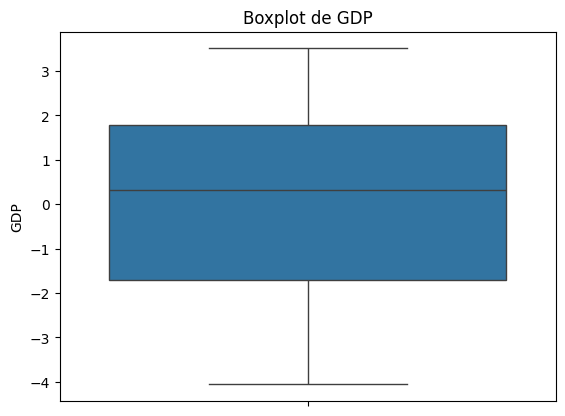

In [ ]:
for numerica in numericas:
  sns.boxplot(data=df,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

realizamos lo mismo con las variables de porcentajes

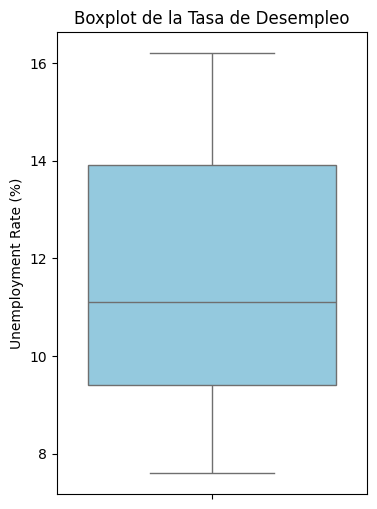

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(data=df, y='Unemployment rate', color='skyblue')
plt.title('Boxplot de la Tasa de Desempleo')
plt.ylabel('Unemployment Rate (%)')
plt.show()

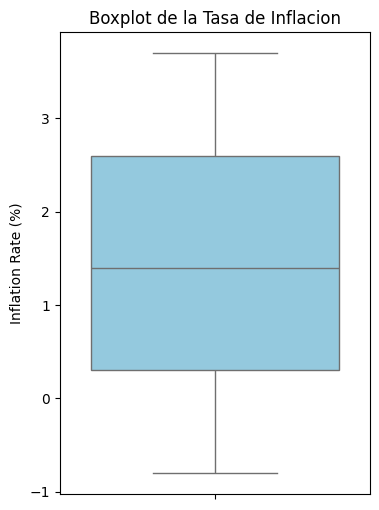

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(data=df, y='Inflation rate', color='skyblue')
plt.title('Boxplot de la Tasa de Inflacion')
plt.ylabel('Inflation Rate (%)')
plt.show()

Podemos observar que en varias de las variables hay datos atipicos muy presentes. Como no son errores, se va a realizar una imputacion a traves de la mediana

In [ ]:
df_copy=df.copy()

In [ ]:
for col in numericas:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median = df_copy[col].median()
    df_copy.loc[(df_copy[col] < lower_bound) | (df_copy[col] > upper_bound), col] = median

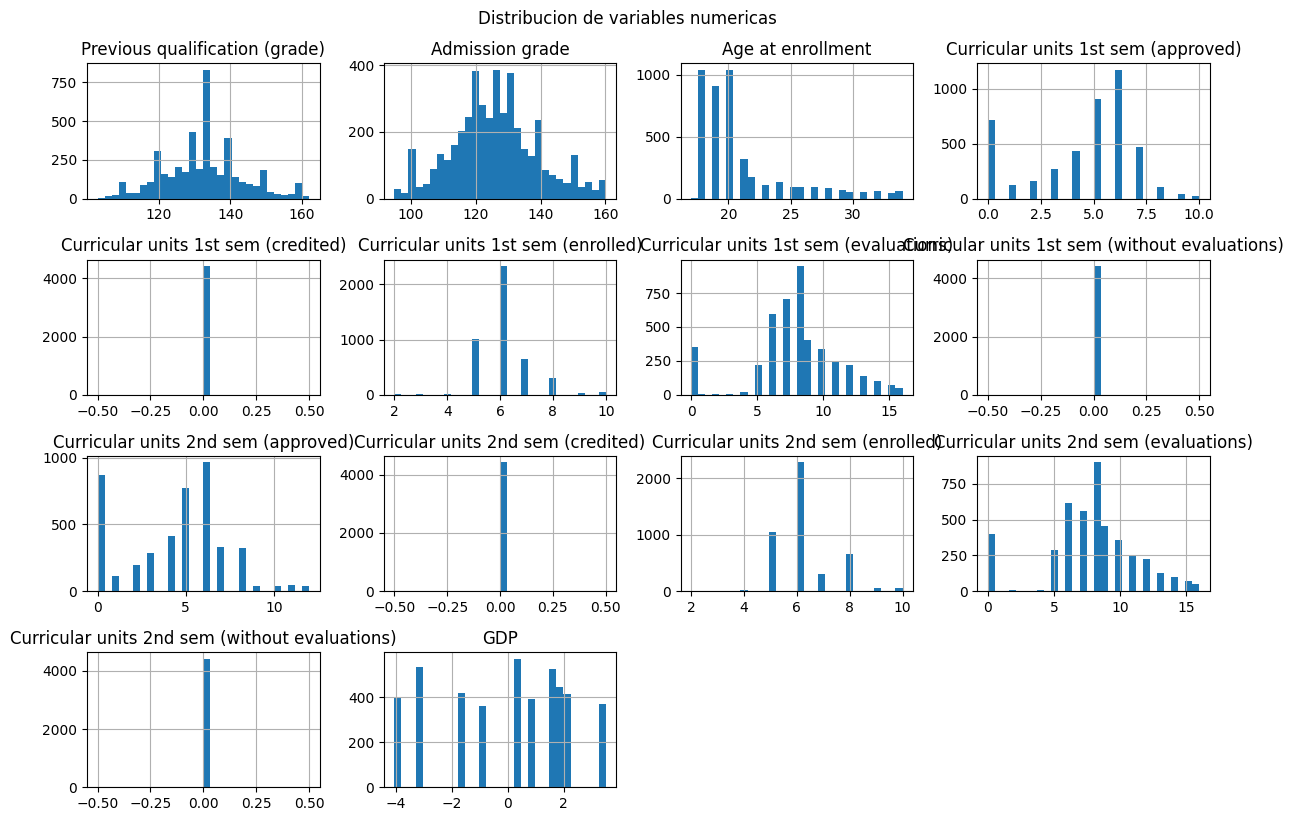

In [ ]:
df_copy[numericas].hist(bins=30,figsize=(12,8))
plt.tight_layout()
plt.suptitle('Distribucion de variables numericas',y=1.02)
plt.show()

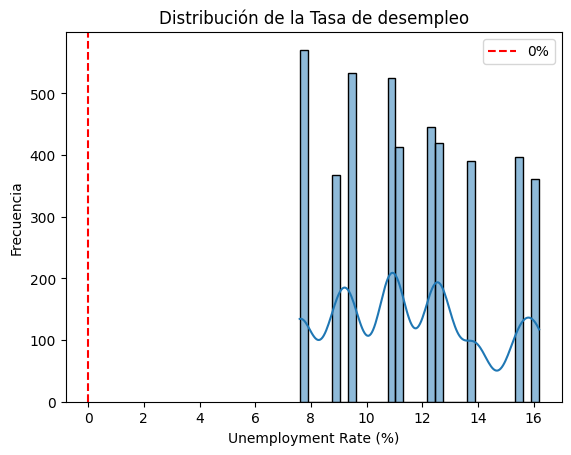

In [ ]:
sns.histplot(data=df_copy, x='Unemployment rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de desempleo')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

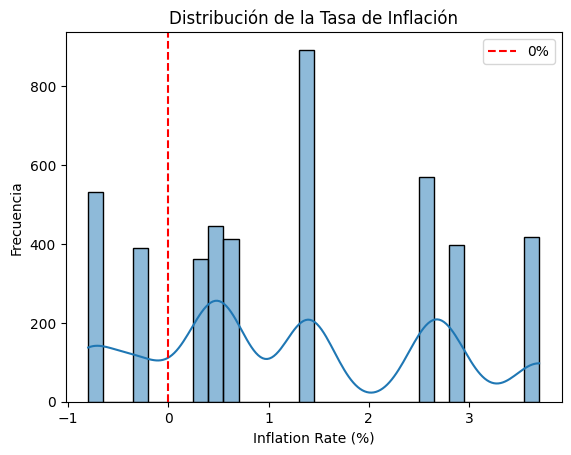

In [ ]:
sns.histplot(data=df_copy, x='Inflation rate', bins=30, kde=True)
plt.title('Distribución de la Tasa de Inflación')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='0%')
plt.legend()
plt.show()

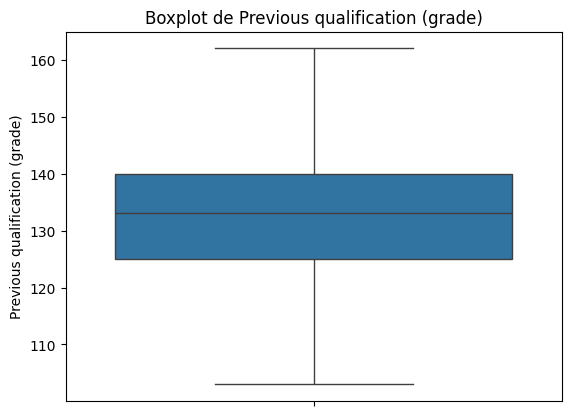

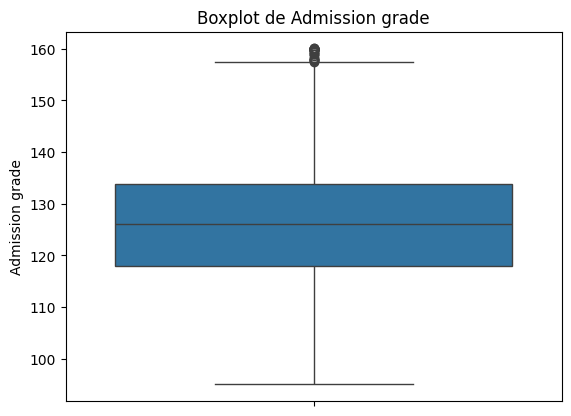

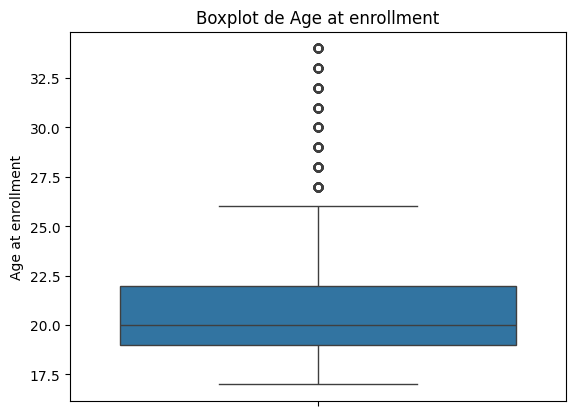

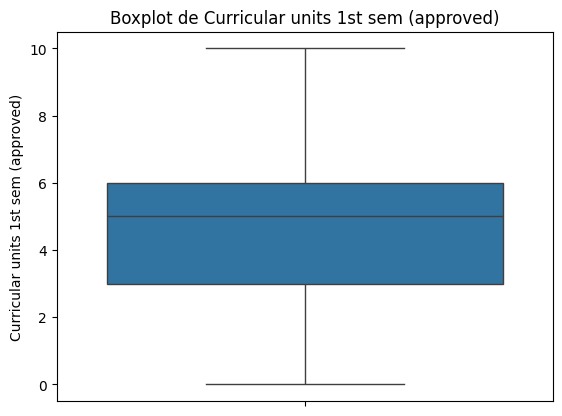

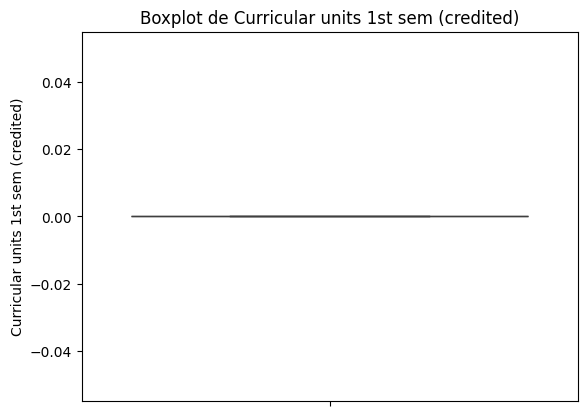

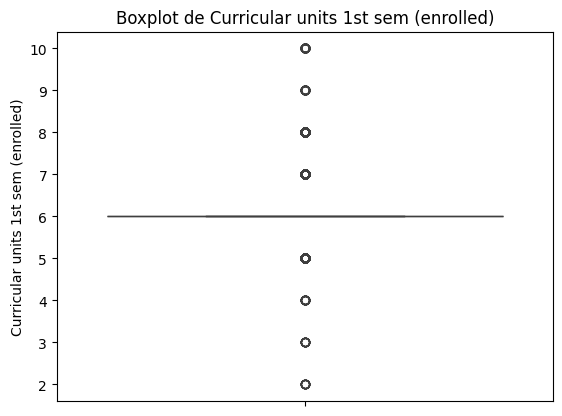

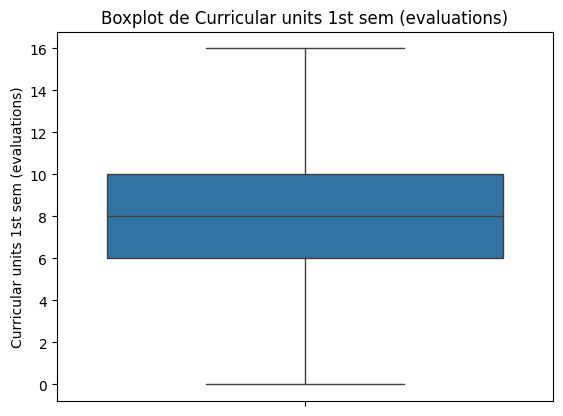

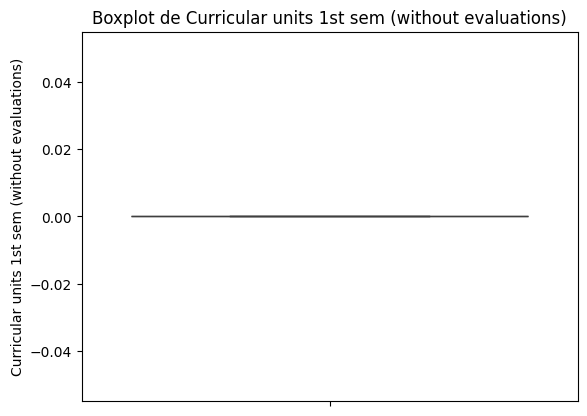

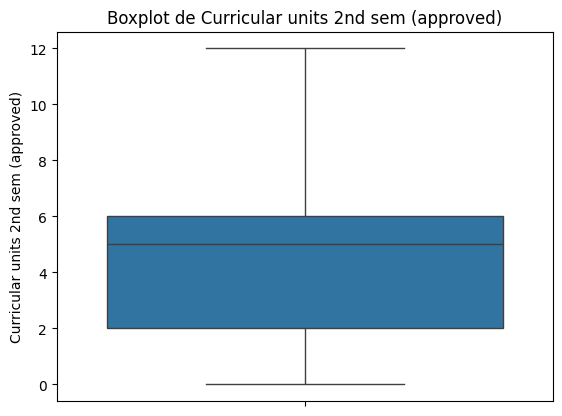

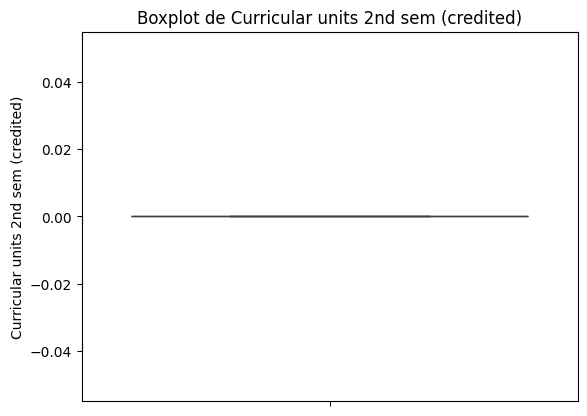

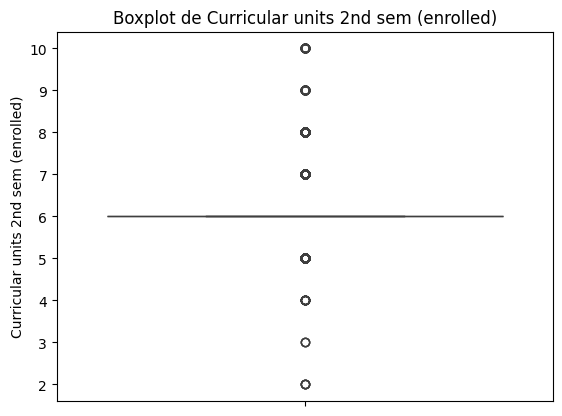

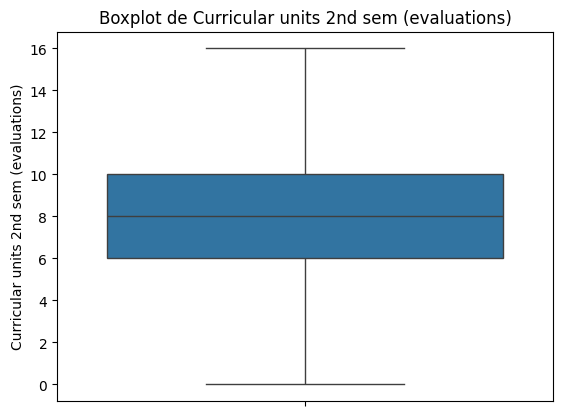

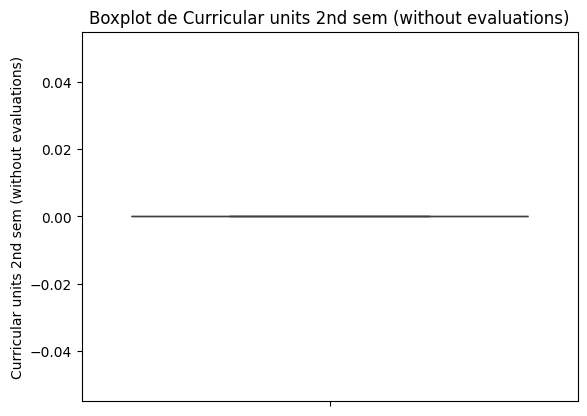

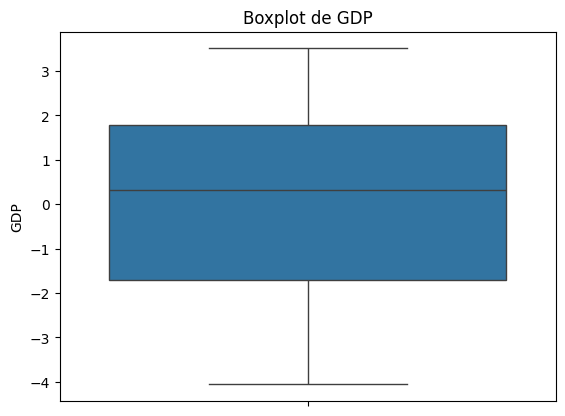

In [ ]:
for numerica in numericas:
  sns.boxplot(data=df_copy,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

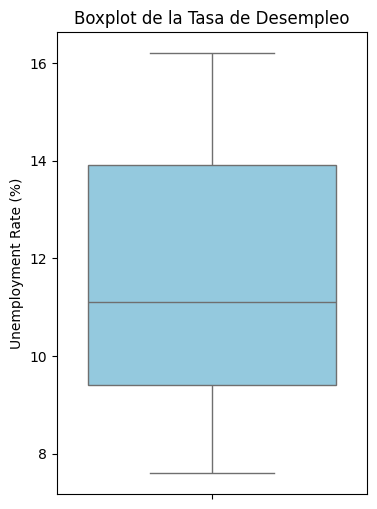

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(data=df_copy, y='Unemployment rate', color='skyblue')
plt.title('Boxplot de la Tasa de Desempleo')
plt.ylabel('Unemployment Rate (%)')
plt.show()


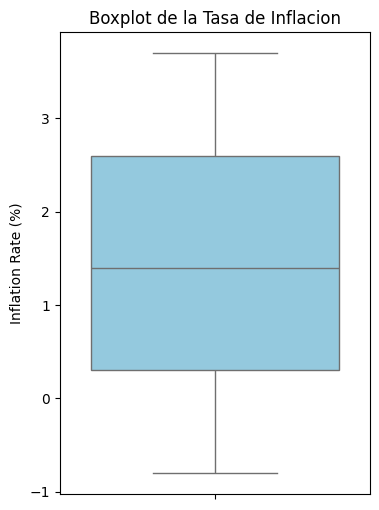

In [ ]:
plt.figure(figsize=(4, 6))
sns.boxplot(data=df_copy, y='Inflation rate', color='skyblue')
plt.title('Boxplot de la Tasa de Inflacion')
plt.ylabel('Inflation Rate (%)')
plt.show()

codificamos las variables que tienen categorias asociadas a ellas y las variables categoricas que existen en el dataframe

Se verifica la distribucion de cada categoria utilizando value_counts

In [ ]:
categoricas=['Marital status','Application mode','Application order','Course','Daytime/evening attendance\t','Previous qualification','Nacionality',"Mother's qualification","Father's qualification","Mother's occupation","Father's occupation",'Displaced','Educational special needs','Debtor','Tuition fees up to date','Gender','Scholarship holder','International','Target']

Marital status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64


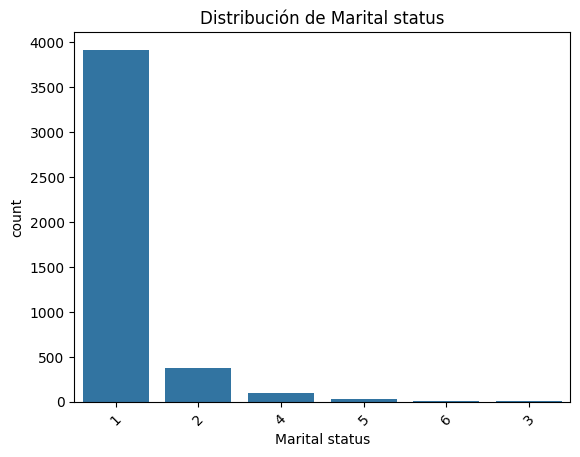

Application mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64


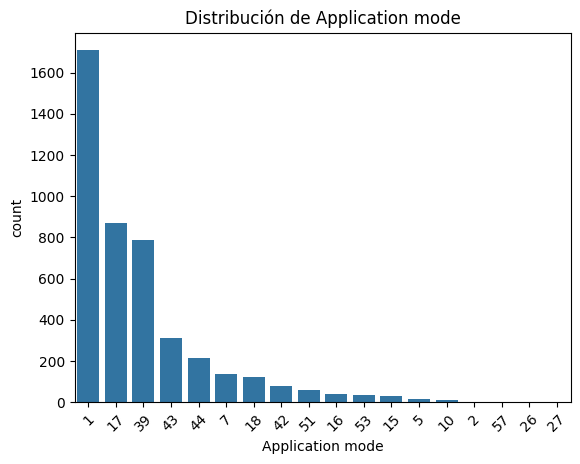

Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64


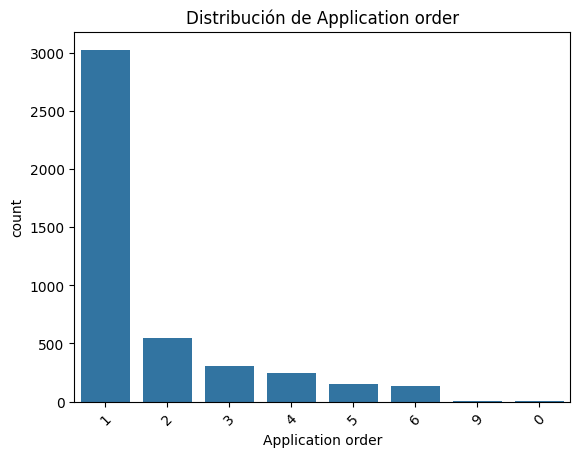

Course
9500    766
9147    380
9238    355
9085    337
9773    331
9670    268
9991    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64


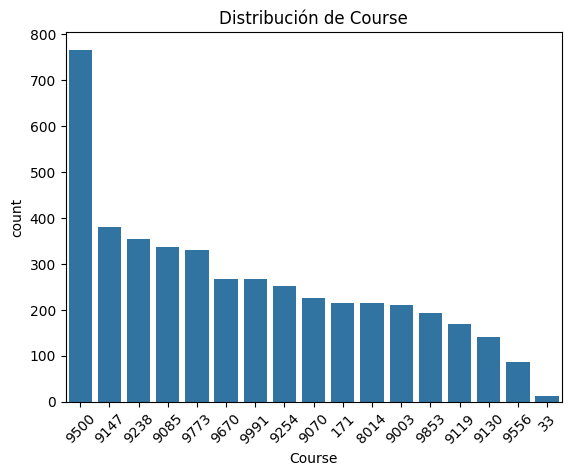

Daytime/evening attendance\t
1    3941
0     483
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


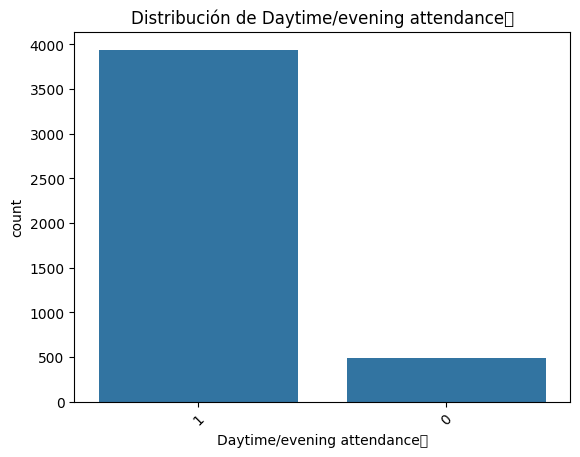

Previous qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2       23
6       16
9       11
4        8
38       7
43       6
10       4
15       2
5        1
14       1
Name: count, dtype: int64


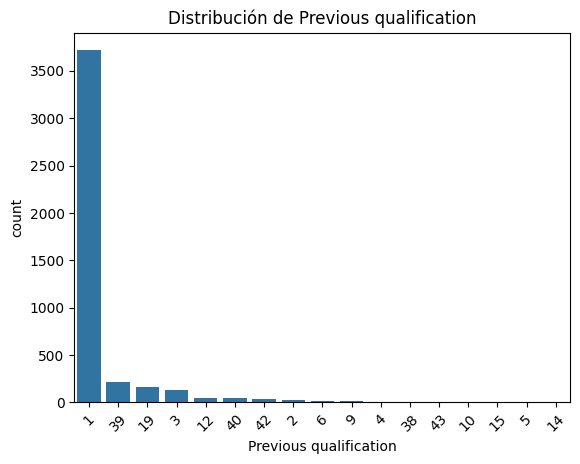

Nacionality
1      4314
41       38
26       14
6        13
22       13
24        5
100       3
11        3
103       3
62        2
21        2
101       2
25        2
2         2
105       2
32        1
13        1
109       1
108       1
14        1
17        1
Name: count, dtype: int64


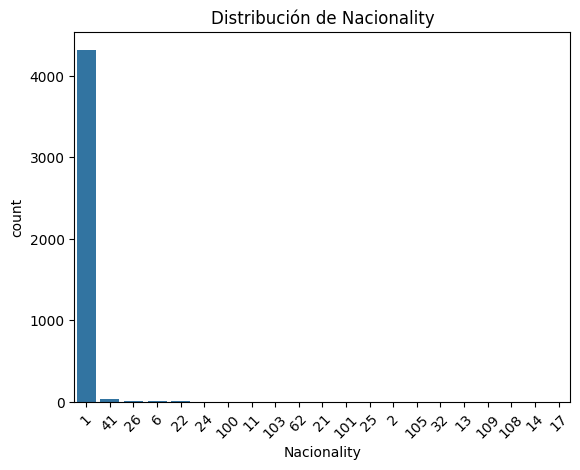

Mother's qualification
1     1069
37    1009
19     953
38     562
3      438
34     130
2       83
4       49
12      42
5       21
40       9
9        8
39       8
41       6
42       4
6        4
43       4
30       3
35       3
36       3
11       3
29       3
10       3
14       2
18       1
22       1
27       1
26       1
44       1
Name: count, dtype: int64


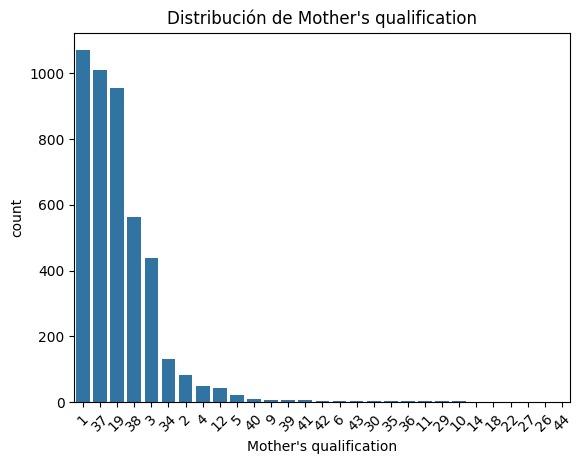

Father's qualification
37    1209
19     968
1      904
38     702
3      282
34     112
2       68
4       39
12      38
39      20
5       18
11      10
36       8
9        5
40       5
14       4
30       4
22       4
29       3
26       2
43       2
41       2
10       2
6        2
35       2
20       1
42       1
18       1
13       1
25       1
44       1
33       1
27       1
31       1
Name: count, dtype: int64


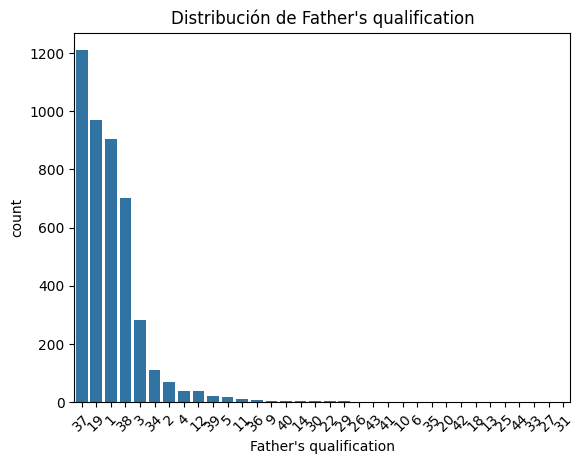

Mother's occupation
9      1577
4       817
5       530
3       351
2       318
7       272
0       144
1       102
6        91
90       70
8        36
191      26
99       17
194      11
141       8
123       7
144       6
175       5
192       5
10        4
134       4
193       4
151       3
132       3
143       3
153       2
152       2
122       2
125       1
173       1
131       1
171       1
Name: count, dtype: int64


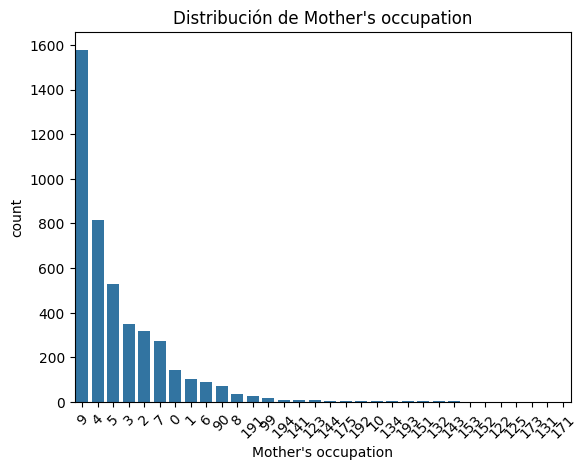

Father's occupation
9      1010
7       666
5       516
4       386
3       384
8       318
10      266
6       242
2       197
1       134
0       128
90       65
99       19
193      15
144       8
171       8
192       6
163       5
103       4
175       4
181       3
135       3
152       3
183       3
123       3
112       2
194       2
182       2
172       2
151       2
102       2
122       2
124       1
131       1
195       1
121       1
132       1
161       1
143       1
134       1
153       1
174       1
141       1
114       1
101       1
154       1
Name: count, dtype: int64


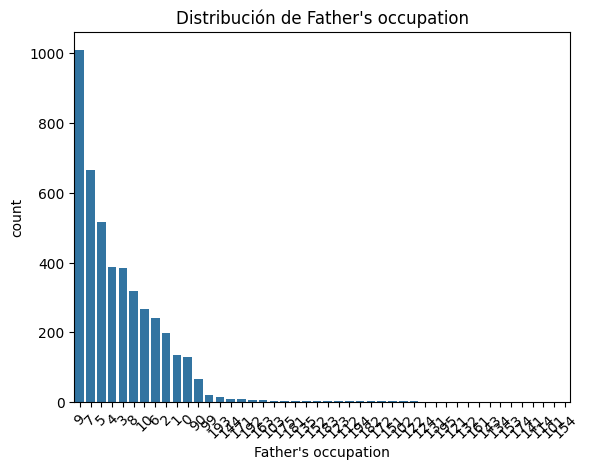

Displaced
1    2426
0    1998
Name: count, dtype: int64


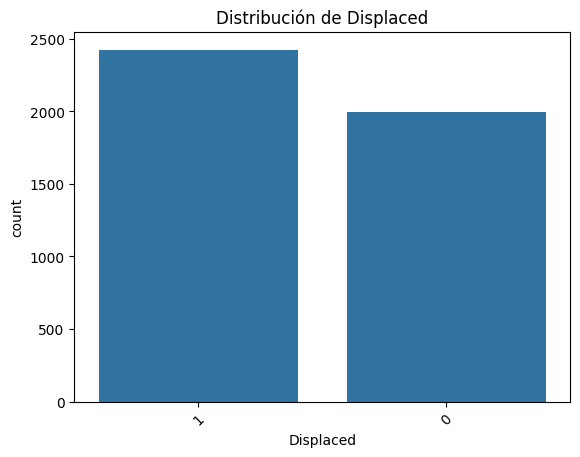

Educational special needs
0    4373
1      51
Name: count, dtype: int64


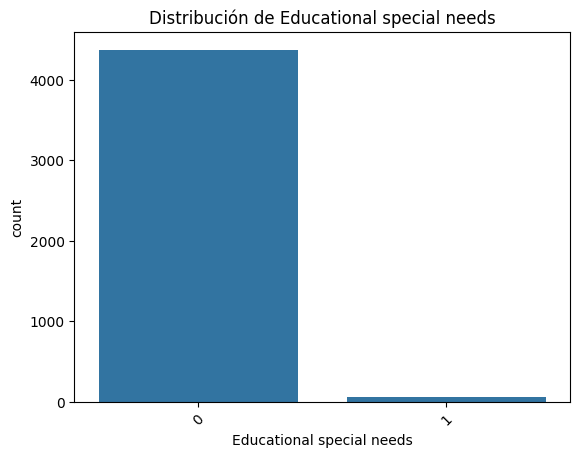

Debtor
0    3921
1     503
Name: count, dtype: int64


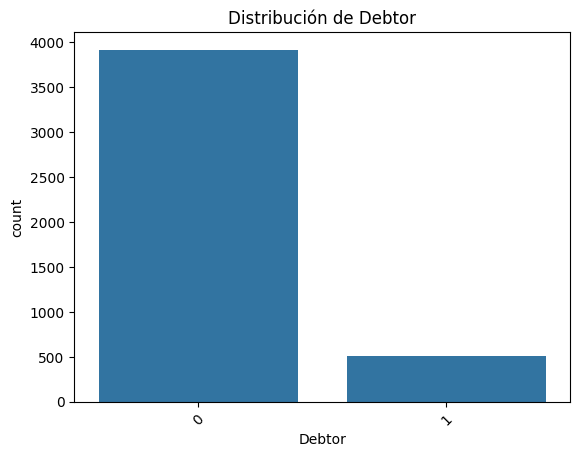

Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64


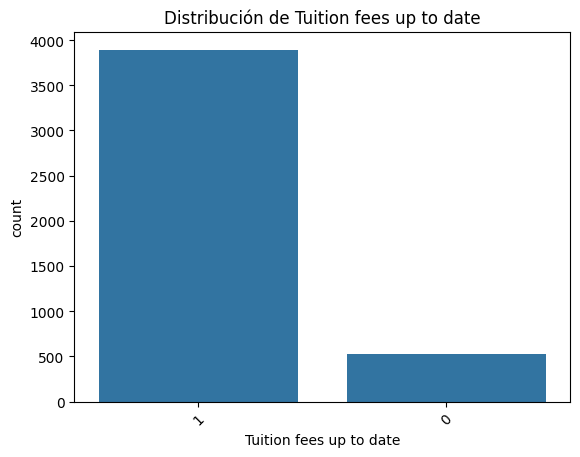

Gender
0    2868
1    1556
Name: count, dtype: int64


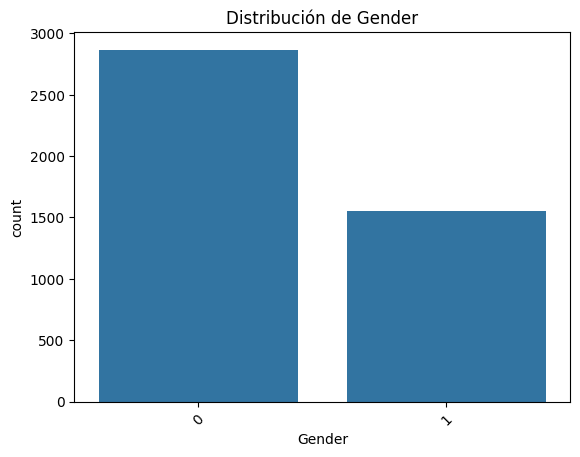

Scholarship holder
0    3325
1    1099
Name: count, dtype: int64


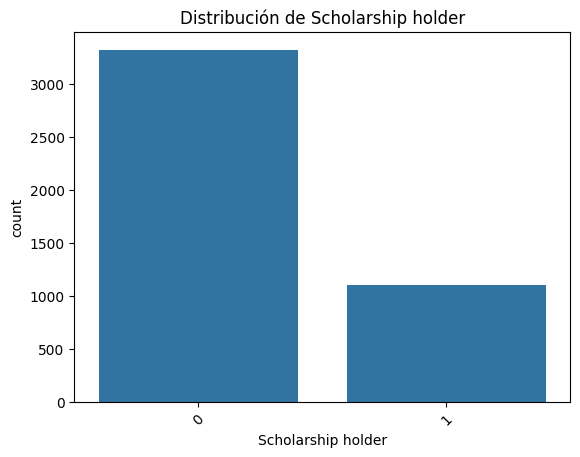

International
0    4314
1     110
Name: count, dtype: int64


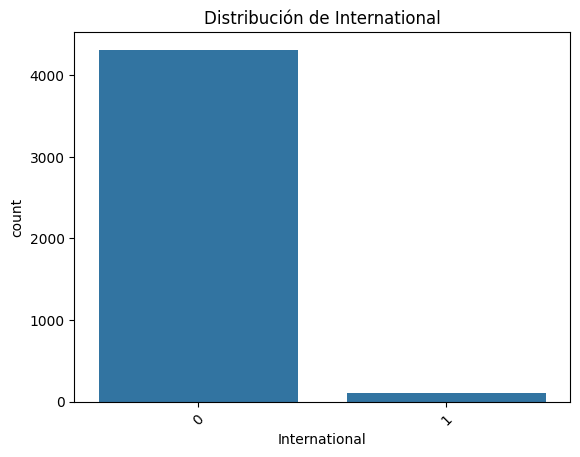

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


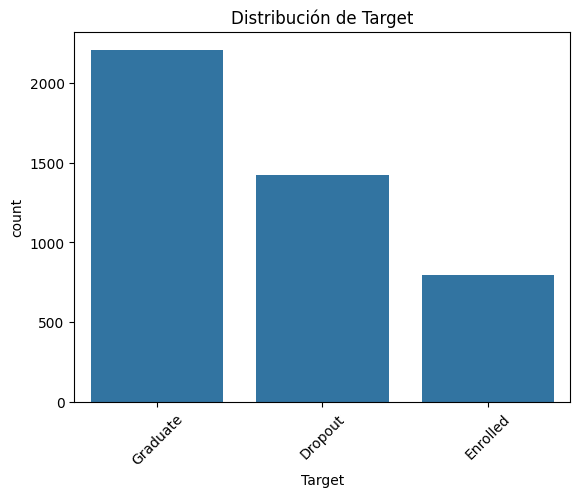

In [ ]:
for col in categoricas:
  print(df_copy[col].value_counts())
  sns.countplot(data=df_copy, x=col, order=df_copy[col].value_counts().index)
  plt.title(f'Distribución de {col}')
  plt.xticks(rotation=45)
  plt.show()

Realizamos la matriz de correlacion

In [ ]:
df_corr=df_copy.drop(columns=['Target'])

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


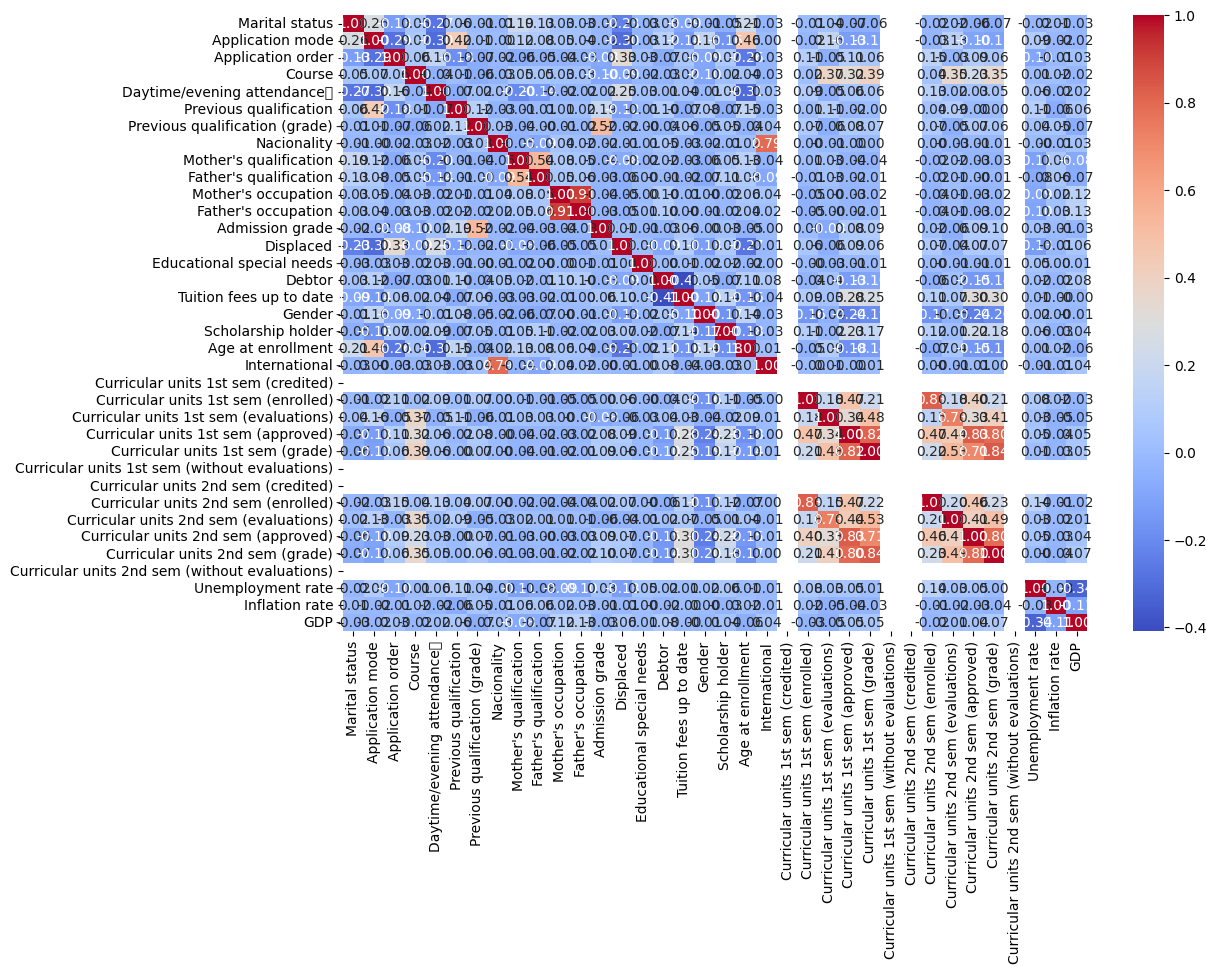

In [ ]:
matriz_corr=df_corr.corr()
plt.figure(figsize=(12,8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

Podemos observar que las variables academicas estan fuertemente correlacionadas entre si y las variables demograficas no tienen una correlacion muy grande con el desempeño academico

#Division de datos

Realizamos la division de los datos antes de realizar la codificacion y la estandarizacion de variables para evitar data leakage utilizando train_test_split

##Clasificacion

In [ ]:
X_clas=df_copy.drop(columns=['Target'])
Y_clas=df_copy['Target']

In [ ]:
X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(X_clas,Y_clas, test_size=0.2, random_state=42, stratify=Y_clas)

#Regresion

#Preprocesamiento de datos

Ahora realizamos el preprocesamiento de datos

Las variables binarias ya estan codificadas como 0 y 1 por lo que se mantienen igual

La variable target y tenemos que reetiquetarla debido a que el objetivo del modelo es determinar si el estudiante es Dropout

In [ ]:
y_train_clas = y_train_clas.apply(lambda x: 1 if x == 'Dropout' else 0)
y_test_clas = y_test_clas.apply(lambda x: 1 if x == 'Dropout' else 0)

Ahora codificamos las variables categoricas empezando por las nominales

Para variables nominales que tengan mas de 15 categorias, podemos agrupar las menos relevantes para luego aplicar one-hot encoding. De esta manera podemos reducirla dimensionalidad y mejorar la calidad de las distancias al aplicar el modelo de KNN

In [ ]:
columnas_agrupar=['Application mode','Course','Nacionality',"Mother's occupation","Father's occupation"]

In [ ]:
X_train_agrupado=agrupacion(X_train_clas,columnas_agrupar,umbral=0.02,categoria_agrupada='-1')

In [ ]:
X_test_agrupado=X_test_clas.copy()
for col in columnas_agrupar:
  freqs_train = X_train_clas[col].value_counts(normalize=True)
  cat_poco_freq = freqs_train[freqs_train < 0.02].index
  X_test_agrupado[col] = aplicar_agrupacion(X_test_clas, col, cat_poco_freq)

In [ ]:
X_train_ohe = pd.get_dummies(X_train_agrupado,columns=columnas_agrupar)
X_test_ohe = pd.get_dummies(X_test_agrupado,columns=columnas_agrupar)

In [ ]:
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

Para las variables ordinales se les realiza el mapeo de las categorias para respetar el orden existente, para luego reemplazarlo en el train y el test

In [ ]:
mapeo_educativo_padres = {
    # 0 = Sin educación
    35: 0,
    36: 0,

    # 1 = Básica primaria incompleta
    37: 1,

    # 2 = Básica primaria completa
    38: 2,
    11: 2,
    26: 2,
    30: 2,

    # 3 = Secundaria incompleta
    29: 3,
    14: 3,
    10: 3,
    12: 3,
    13: 3,
    25: 3,

    # 4 = Secundaria completa
    19: 4,
    27: 4,
    1: 4,
    18: 4,
    20: 4,

    # 5 = Técnico/profesional incompleto
    22: 5,
    39: 5,
    31: 5,

    # 6 = Técnico/profesional completo
    40: 6,
    41: 6,
    42: 6,
    33: 6,

    # 7 = Universitario incompleto
    9: 7,

    # 8 = Universitario completo
    2: 8,
    3: 8,

    # 9 = Postgrado
    4: 9,
    43: 9,
    5: 9,
    44: 9,

    # Desconocido
    34: None
}

In [ ]:
X_train_ohe["Mother's qualification"]=X_train_ohe["Mother's qualification"].map(mapeo_educativo_padres)
X_train_ohe["Father's qualification"]=X_train_ohe["Father's qualification"].map(mapeo_educativo_padres)
X_test_ohe["Mother's qualification"]=X_test_ohe["Mother's qualification"].map(mapeo_educativo_padres)
X_test_ohe["Father's qualification"]=X_test_ohe["Father's qualification"].map(mapeo_educativo_padres)

mediana_madre=X_train_ohe["Mother's qualification"].median()
mediana_padre=X_train_ohe["Father's qualification"].median()
X_train_ohe["Mother's qualification"] = X_train_ohe["Mother's qualification"].fillna(mediana_madre)
X_train_ohe["Father's qualification"] = X_train_ohe["Father's qualification"].fillna(mediana_padre)
X_test_ohe["Mother's qualification"] = X_test_ohe["Mother's qualification"].fillna(mediana_madre)
X_test_ohe["Father's qualification"] = X_test_ohe["Father's qualification"].fillna(mediana_padre)

In [ ]:
X_train_OH = pd.get_dummies(X_train_ohe,'Marital status')
X_test_OH = pd.get_dummies(X_test_ohe,'Marital status')

Con previous_qualification como existen algunas categorias que en los de los padres no estan se realiza su mapeo por separado

In [ ]:
map_educacion = {
    # 1 = Educación básica incompleta o en curso
    9: 1,
    10: 1,
    12: 1,
    15: 1,

    # 2 = Educación básica completa
    38: 2,
    19: 2,
    14: 2,

    # 3 = Secundaria completa
    1: 3,

    # 4 = Educación técnica / profesional
    39: 4,
    42: 4,

    # 5 = Educación superior - grado / licenciatura
    2: 5,
    3: 5,
    40: 5,

    # 6 = Educación superior - máster
    4: 6,
    43: 6,

    # 7 = Educación superior - doctorado
    5: 7,

    # 9 = Otro / Ambiguo
    6: 9,
}


In [ ]:
X_train_OH['Previous qualification']=X_train_OH['Previous qualification'].map(map_educacion)
X_test_OH['Previous qualification']=X_test_OH['Previous qualification'].map(map_educacion)

Ya se codificaron todas las categoricas. Por lo tanto falta escalar las variables numericas y las variables mapeadas para poder utilizar KNN

In [ ]:
Numericas=['Application order','Previous qualification','Previous qualification (grade)',"Mother's qualification","Father's qualification",'Admission grade','Age at enrollment','Curricular units 1st sem (approved)','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (without evaluations)',
'Curricular units 2nd sem (approved)','Curricular units 2nd sem (credited)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (without evaluations)','Unemployment rate','Inflation rate','GDP']

In [ ]:
scaler=MinMaxScaler()
X_train_OH[Numericas] = scaler.fit_transform(X_train_OH[Numericas])
X_test_OH[Numericas] = scaler.transform(X_test_OH[Numericas])

Ahora con todas las variables preparadas podemos comenzar el modelo de KNN

#KNN